<a href="https://colab.research.google.com/github/rreap/stocks/blob/main/Stocks_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")

In [ ]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [ ]:
print(data.isnull().sum())
data = data.dropna()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64


In [ ]:
print(f"Duplicates: {data.duplicated().sum()}")

Duplicates: 0


In [ ]:
data = data.drop_duplicates()

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
std,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07
min,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08


In [ ]:
data = data.drop(columns=['Adj Close'])

In [ ]:
data.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,164101200,AAPL


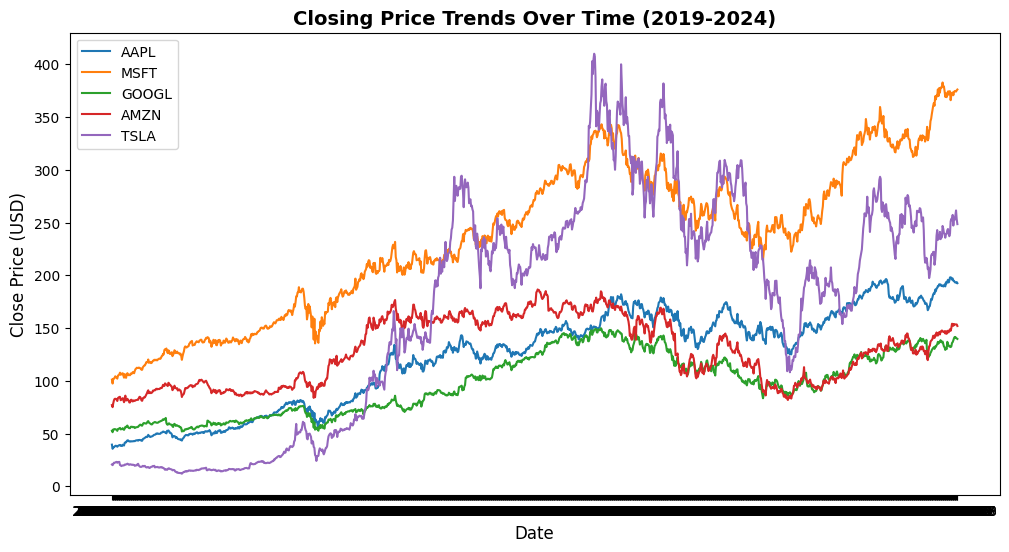

In [26]:
plt.figure(figsize=(12, 6))
sample_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
subset = data[data["Ticker"].isin(sample_tickers)]

for ticker in sample_tickers:
  ticker_data = subset[subset["Ticker"] == ticker]
  plt.plot(
      ticker_data["Date"], ticker_data["Close"], label=ticker
  )

plt.title(
    "Closing Price Trends Over Time (2019-2024)", fontsize=14, fontweight="bold"
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (USD)", fontsize=12)
plt.legend()
plt.show()

In [25]:
data["Close_Rolling_Mean_30"] = (
    data.groupby("Ticker")["Close"].rolling(window=30).mean().reset_index(level=0, drop=True)
)

data["Close_Rolling_Std_30"] = (
    data.groupby("Ticker")["Close"].rolling(window=30).std().reset_index(level=0, drop=True)
)
data.head(31)

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Close_Rolling_Mean_30,Close_Rolling_Std_30
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL,NaN,NaN
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL,NaN,NaN
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL,NaN,NaN
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL,NaN,NaN
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL,NaN,NaN
5,2019-01-09,37.822498,38.632500,37.407501,38.327499,36.690502,180396400,AAPL,NaN,NaN
6,2019-01-10,38.125000,38.492500,37.715000,38.450001,36.807777,143122800,AAPL,NaN,NaN
7,2019-01-11,38.220001,38.424999,37.877499,38.072498,36.446388,108092800,AAPL,NaN,NaN
8,2019-01-14,37.712502,37.817501,37.305000,37.500000,35.898346,129756800,AAPL,NaN,NaN
9,2019-01-15,37.567501,38.347500,37.512501,38.267502,36.633076,114843600,AAPL,NaN,NaN


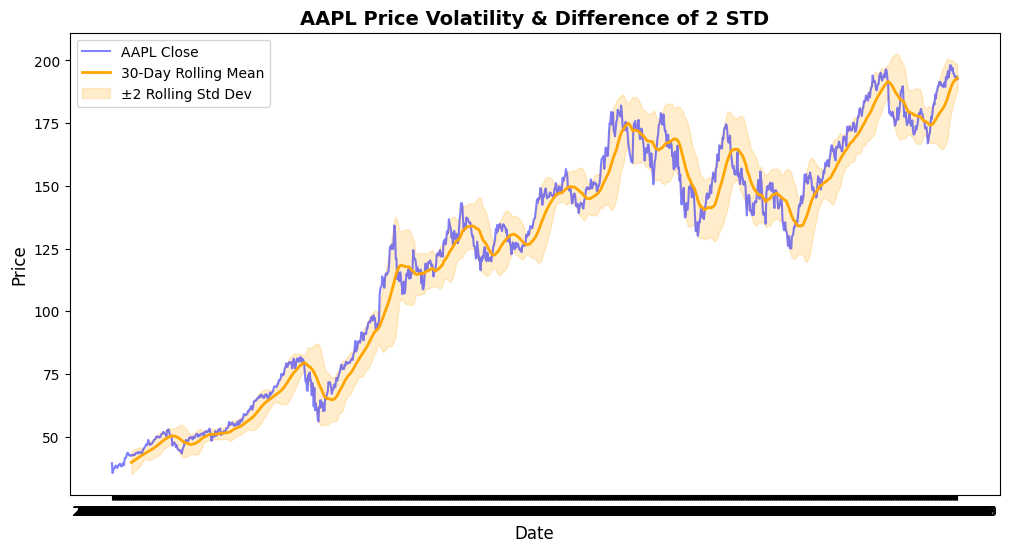

In [ ]:
aapl = data[data["Ticker"] == "AAPL"].copy()
aapl["Rolling_Mean"] = aapl["Close"].rolling(window=30).mean()
aapl["Rolling_Std"] = aapl["Close"].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(
    aapl["Date"], aapl["Close"], label="AAPL Close", color="blue", alpha=0.5
)
plt.plot(
    aapl["Date"],
    aapl["Rolling_Mean"],
    label="30-Day Rolling Mean",
    color="orange",
    lw=2,
)
plt.fill_between(
    aapl["Date"],
    aapl["Rolling_Mean"] - 2 * aapl["Rolling_Std"],
    aapl["Rolling_Mean"] + 2 * aapl["Rolling_Std"],
    color="orange",
    alpha=0.2,
    label="±2 Rolling Std Dev",
)

plt.title(
    "AAPL Price Volatility & Difference of 2 STD",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.show()